<a href="https://colab.research.google.com/github/hrickribeiros/ciencias-de-dados-3ds/blob/main/3DS_Regressao_linear_com_Scikit_Learn_matrizV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⏩EXEMPLO DE PROJETO COM APLICAÇÃO DE REGRESSÃO LINEAR



💡 **LEIA COM ATENÇÃO, FAÇA A SUA CÓPIA DESTE ARQUIVO E COMPLETE AS CÉLULAS DE CÓDIGO ANTES DE EXECUTÁ-LAS!**  

<p align='justify'> Siga as instruções do Classroom, complete as células de código e execute uma por uma para entender como a análise pode ser feita.</p>

## 📦Passo 1: Importando as Ferramentas

In [1]:
import sys
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Exibe as versões das ferramentas instaladas no ambiente
print("--- Versões das Ferramentas Instaladas ---")
print(f"Python:     {sys.version.split()[0]}")
print(f"Pandas:     {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Scikit-Learn: {sklearn.__version__}")
print("-----------------------------------------")


--- Versões das Ferramentas Instaladas ---
Python:     3.13.15
Pandas:     2.2.3
Matplotlib: 3.10.0
Scikit-Learn: 1.6.1
-----------------------------------------



<p align='justify'><b>☝ O que está acontecendo:</b> O pandas vai gerenciar a tabela. O train_test_split vai separar os dados para teste. O LinearRegression é o algoritmo que vai aprender a lógica, e o matplotlib.pyplot servirá para desenhar o gráfico no final.</p>

## 📂 Passo 2: Carregando a Base de Dados  
Precisamos trazer o arquivo de dados (geralmente uma planilha) para dentro do ambiente de programação.

Salve uma cópia do [DATASET](https://drive.google.com/file/d/1woaa_lJezNmTpJII4xA-nIppj-vv8HPC/view?usp=sharing) no computador, carregue o arquivo na pasta do Colab. Complete a célula 2:

In [2]:
data = pd.read_csv('/content/dataset-imoveis.csv', sep=';')

# 2.2 Visualiza primeiras linhas do dataset
data.head()


,Valor,Area,Dist_Praia,Dist_Farmacia
0,4600000,280,0.240925,0.793637
1,900000,208,0.904136,0.134494
2,2550000,170,0.059525,0.423318
3,550000,100,2.883181,0.525064
4,2200000,164,0.239758,0.192374



<p align='justify'><b>☝ O que está acontecendo:</b> O comando pd.read_csv lê o arquivo da internet. Usamos o sep=';' porque planilhas brasileiras usam ponto e vírgula para separar as colunas. O data.head() serve para espiar se a tabela foi carregada corretamente.</p>

## 🎯 Passo 3: Separando as variáveis independentes e dependente

In [3]:
# X maiúsculo = Características/Pistas (Matriz de dados)
X = data[['Area', 'Dist_Praia', 'Dist_Farmacia']]

# y minúsculo = O que queremos adivinhar (Vetor de respostas)
y = data['Valor']

# Mostra na tela as variáveis separadas
print(X)
print(y)

      Area  Dist_Praia  Dist_Farmacia
0      280    0.240925       0.793637
1      208    0.904136       0.134494
2      170    0.059525       0.423318
3      100    2.883181       0.525064
4      164    0.239758       0.192374
...    ...         ...            ...
4995    70    0.479357       0.752891
4996   128    8.594487       0.370170
4997    70    0.253138       0.421407
4998    55    8.945226       0.680963
4999    94    0.774444       0.027916

[5000 rows x 3 columns]
0       4600000
1        900000
2       2550000
3        550000
4       2200000
         ...   
4995     735000
4996     900000
4997     800000
4998     190000
4999     550000
Name: Valor, Length: 5000, dtype: int64



<p align='justify'><b>☝ O que está acontecendo:</b> Separamos o problema em duas partes. No X, colocamos o tamanho da casa e as distâncias (as causas). No y, colocamos o preço do imóvel (o efeito).</p>

## ✂️ Passo 4: Divisão dos Dados

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Cria tabela resumida para ver como o Pandas fatiou o dataset
tabela_divisao = pd.DataFrame({
    'Grupo de Dados': ['Treino (Estudo)', 'Teste (Prova Surpresa)', 'Total da Base'],
    'Quantidade de Imóveis': [len(X_train), len(X_test), len(data)],
    'Proporção': ['80%', '20%', '100%']
})

# Exibe a tabela estruturada na tela
display(tabela_divisao)

,Grupo de Dados,Quantidade de Imóveis,Proporção
0,Treino (Estudo),4000,80%
1,Teste (Prova Surpresa),1000,20%
2,Total da Base,5000,100%



<p align='justify'><b>☝ O que está acontecendo:</b> O comando divide a tabela automaticamente. Separamos 80% dos dados para o robô estudar (X_train e y_train) e guardamos 20% (test_size=0.2) para fazer uma prova surpresa com ele depois (X_test e y_test).</p>

## 🧠 Passo 5: Criando e Treinando o Modelo

In [5]:
# A) Instancia um cérebro de regressão linear em branco
model = LinearRegression()

# B) Alimenta o modelo com os dados de treino para aprender a lógica
model.fit(X_train, y_train)

LinearRegression()

<p align='justify'><b>☝ O que está acontecendo:</b> O comando .fit() significa "ajustar" ou "treinar". É o momento exato em que a Inteligência Artificial calcula a linha de tendência que melhor se adapta aos dados informados.</p>

## 📊 Passo 6: Exibindo coeficientes encontrados pela IA

In [6]:
# Imprime título do mini relatório na tela
print("\n--- Coeficientes Encontrados pela IA ---")

# Laço for  formata a exibição do relatório na tela
for coluna, peso in zip(X.columns, model.coef_):
    print(f"Peso de '{coluna}': {peso:.2f}")


--- Coeficientes Encontrados pela IA ---
Peso de 'Area': 13511.35
Peso de 'Dist_Praia': -106898.83
Peso de 'Dist_Farmacia': 36878.62


<p align='justify'><b>☝ O que está acontecendo:</b> O código faz uma varredura nas colunas e exibe os pesos (coeficientes). Valores positivos indicam que quanto maior é a variável, maior será preço (ex: Área). Valores negativos indicam o inverso: quanto maior é a distância da praia, menor será o valor do imóvel.</p>

## 📈 Passo 7: Visualizando o desempenho em gráfico

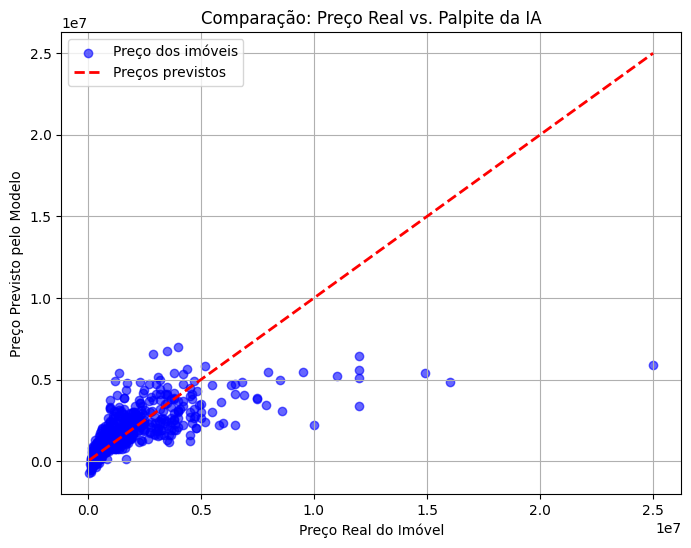

In [7]:
# Modelo produz palpites com os dados de teste
palpites = model.predict(X_test)

# Configura o tamanho do gráfico
plt.figure(figsize=(8, 6))

# Plota os pontos reais (Preço Real vs Palpite do robô)
plt.scatter(y_test, palpites, color='blue', alpha=0.6, label='Preço dos imóveis')

# Desenha uma linha perfeita de referência (onde o palpite seria 100% igual ao real)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Preços previstos')

# Adiciona títulos e legendas ao gráfico
plt.title('Comparação: Preço Real vs. Palpite da IA')
plt.xlabel('Preço Real do Imóvel')
plt.ylabel('Preço Previsto pelo Modelo')
plt.legend()
plt.grid(True)

# Exibe o gráfico na tela
plt.show()

<p align='justify'><b>☝ O que está acontecendo:</b> O comando model.predict() coloca o modelo à prova. No gráfico, a linha vermelha representa o acerto perfeito. Quanto mais os pontos azuis estiverem alinhados e colados a ela, mais precisa é a sua Inteligência Artificial!</P>


## 🎉 Parabéns por chegar ao final deste notebook.   
- Clique em "Salvar e fixar versão".
- Salve esta cópia no repositório de Ciência de Dados do seu GitHub; clique em "Salvar uma cópia no GitHub" (Passo 8).